In [43]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [44]:
import pandas as pd 

df = pd.read_csv("C:/Users/SnehaG/Downloads/fda_adverse_events_2015_2026_CLEAN.csv")

print(df.head(10))

   report_id receive_date  year  month quarter serious    serious_flags  \
0   10004718   2015-02-11  2015      2  2015Q1     Yes  Hospitalization   
1   10004926   2015-02-13  2015      2  2015Q1     Yes  Hospitalization   
2   10005223   2015-02-19  2015      2  2015Q1     Yes  Hospitalization   
3   10005378   2015-02-17  2015      2  2015Q1     Yes  Hospitalization   
4   10005980   2015-02-21  2015      2  2015Q1     Yes              NaN   
5   10006058   2015-02-26  2015      2  2015Q1     Yes              NaN   
6   10006362   2015-02-05  2015      2  2015Q1     Yes       Disability   
7   10006367   2015-02-17  2015      2  2015Q1     Yes              NaN   
8   10006374   2015-02-17  2015      2  2015Q1     Yes              NaN   
9   10006394   2015-02-27  2015      2  2015Q1     Yes              NaN   

   is_fatal  is_hospitalized  is_life_threat  ...  \
0     False             True           False  ...   
1     False             True           False  ...   
2     False    

In [45]:
# Check Data
df.info()
df.isnull().sum()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 528000 entries, 0 to 527999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   report_id            528000 non-null  int64  
 1   receive_date         528000 non-null  str    
 2   year                 528000 non-null  int64  
 3   month                528000 non-null  int64  
 4   quarter              528000 non-null  str    
 5   serious              528000 non-null  str    
 6   serious_flags        226894 non-null  str    
 7   is_fatal             528000 non-null  bool   
 8   is_hospitalized      528000 non-null  bool   
 9   is_life_threat       528000 non-null  bool   
 10  is_disabling         528000 non-null  bool   
 11  reactions            528000 non-null  str    
 12  primary_reaction     528000 non-null  str    
 13  reaction_outcomes    528000 non-null  str    
 14  patient_recovered    528000 non-null  bool   
 15  num_reactions        528000 

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,NaN,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,NaN,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,NaN,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,NaN,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),NaN,Unknown,Female,NaN,GB,4053


In [46]:
# Cleaning Dataset

In [47]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [48]:
# Fill serious flags
df['serious_flags'] = df['serious_flags'].fillna('Not Specified')

In [49]:
# Fill age
df['patient_age_years'] = df['patient_age_years'].fillna(
    df['patient_age_years'].median())

In [50]:
# Fill patient weight
df['patient_weight_kg'] = df['patient_weight_kg'].fillna('Not Specified')

In [51]:
print(df.isnull().sum())

report_id              0
receive_date           0
year                   0
month                  0
quarter                0
serious                0
serious_flags          0
is_fatal               0
is_hospitalized        0
is_life_threat         0
is_disabling           0
reactions              0
primary_reaction       0
reaction_outcomes      0
patient_recovered      0
num_reactions          0
suspect_drug           0
brand_name             0
drug_route             0
drug_indication        0
manufacturer           0
pharm_class            0
num_drugs              0
drug_count_category    0
patient_age_years      0
age_group              0
patient_sex            0
patient_weight_kg      0
country                0
report_age_days        0
dtype: int64


In [52]:
df.head(10)

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,Not Specified,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54.0,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,Not Specified,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,False,True,False,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,Not Specified,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,Not Specified,False,False,False,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),59.0,Unknown,Female,Not Specified,GB,4053
5,10006058,2015-02-26,2015,2,2015Q1,Yes,Not Specified,False,False,False,...,"Janssen Pharmaceuticals, Inc.",Factor Xa Inhibitor [EPC],3,2-3 Drugs,71.0,Senior(66-80),Female,Not Specified,SE,4048
6,10006362,2015-02-05,2015,2,2015Q1,Yes,Disability,False,False,False,...,Parke-Davis Div Of Pfizer Inc; Viatris Special...,Unknown,4,4-5 Drugs,44.0,Middle-Aged(41-65),Female,58.0,US,4069
7,10006367,2015-02-17,2015,2,2015Q1,Yes,Not Specified,False,False,False,...,Parke-Davis Div Of Pfizer Inc; Viatris Special...,Unknown,8,Polypharmacy(6+),69.0,Senior(66-80),Female,73.0,US,4057
8,10006374,2015-02-17,2015,2,2015Q1,Yes,Not Specified,False,False,False,...,Parke-Davis Div Of Pfizer Inc; Viatris Special...,Unknown,8,Polypharmacy(6+),54.0,Middle-Aged(41-65),Female,Not Specified,US,4057
9,10006394,2015-02-27,2015,2,2015Q1,Yes,Not Specified,False,False,False,...,Parke-Davis Div Of Pfizer Inc; Viatris Special...,Unknown,8,Polypharmacy(6+),48.0,Middle-Aged(41-65),Female,57.0,US,4047


In [53]:
# Exploratory Data Analysis (EDA)

In [54]:
# Basic Dataset Overview
print(df.shape)          # Shape of dataset
print(df.columns)        # Column names
print(df.dtypes)         # Data types
print(df.describe())     # Statistical summary

(528000, 30)
Index(['report_id', 'receive_date', 'year', 'month', 'quarter', 'serious',
       'serious_flags', 'is_fatal', 'is_hospitalized', 'is_life_threat',
       'is_disabling', 'reactions', 'primary_reaction', 'reaction_outcomes',
       'patient_recovered', 'num_reactions', 'suspect_drug', 'brand_name',
       'drug_route', 'drug_indication', 'manufacturer', 'pharm_class',
       'num_drugs', 'drug_count_category', 'patient_age_years', 'age_group',
       'patient_sex', 'patient_weight_kg', 'country', 'report_age_days'],
      dtype='str')
report_id                int64
receive_date               str
year                     int64
month                    int64
quarter                    str
serious                    str
serious_flags              str
is_fatal                  bool
is_hospitalized           bool
is_life_threat            bool
is_disabling              bool
reactions                  str
primary_reaction           str
reaction_outcomes          str
patient_reco

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

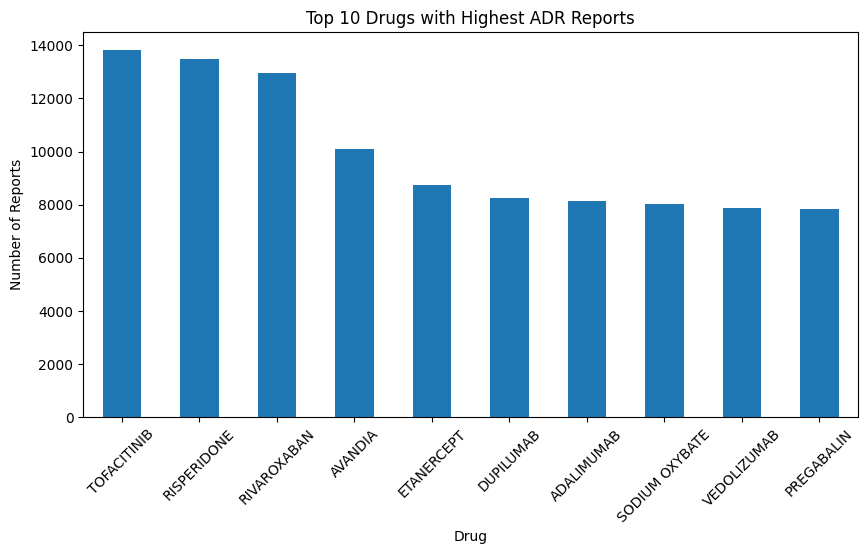

In [56]:
# Top 10 Drugs with Highest ADR Reports

top_drugs = df['suspect_drug'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_drugs.plot(kind='bar')
plt.title('Top 10 Drugs with Highest ADR Reports')
plt.xlabel('Drug')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45)
plt.show()

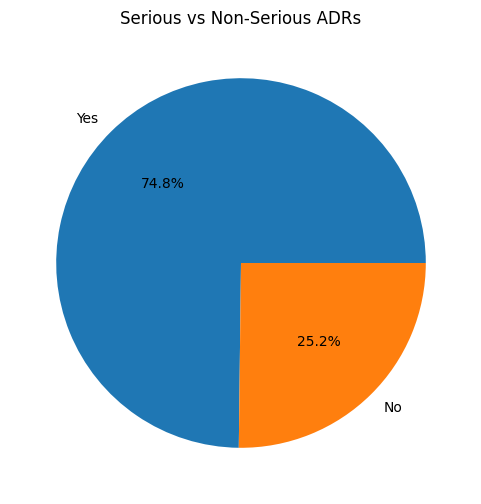

In [57]:
# Serious vs Non-Serious Reports

df['serious'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6))

plt.title('Serious vs Non-Serious ADRs')
plt.ylabel('')
plt.show()

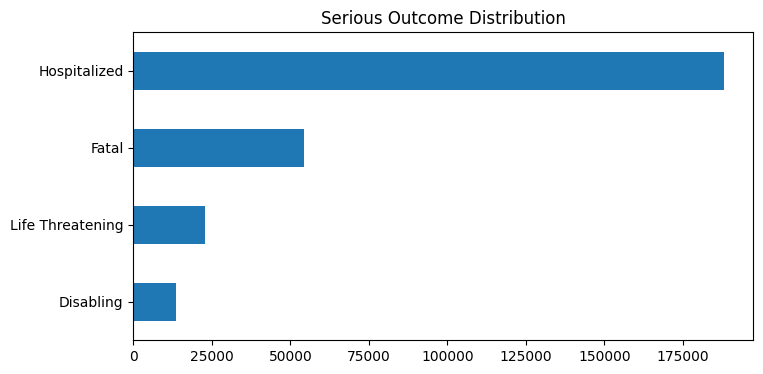

In [58]:
# Most Common Serious Outcome

outcomes = {'Fatal': df['is_fatal'].sum(),
    'Hospitalized': df['is_hospitalized'].sum(),
    'Life Threatening': df['is_life_threat'].sum(),
    'Disabling': df['is_disabling'].sum()}

pd.Series(outcomes).sort_values().plot(
    kind='barh',
    figsize=(8,4))

plt.title('Serious Outcome Distribution')
plt.show()

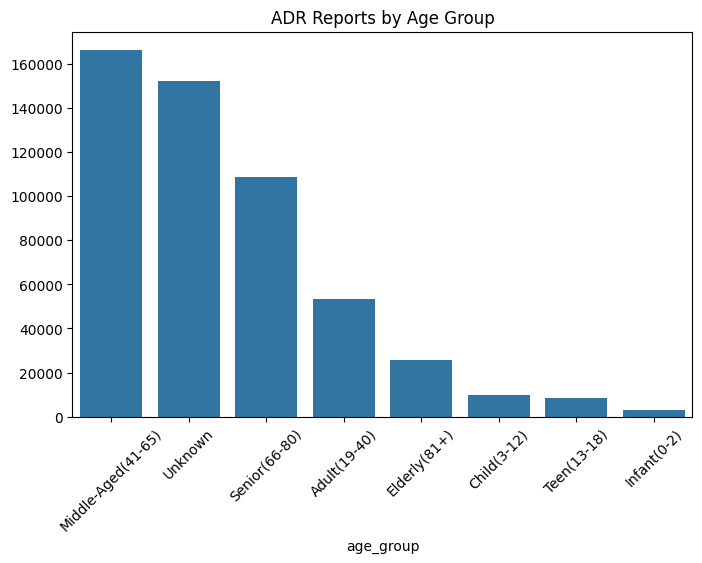

In [59]:
# ADR Reports by Age Group

age_counts = df['age_group'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=age_counts.index,
    y=age_counts.values)

plt.xticks(rotation=45)
plt.title('ADR Reports by Age Group')
plt.show()

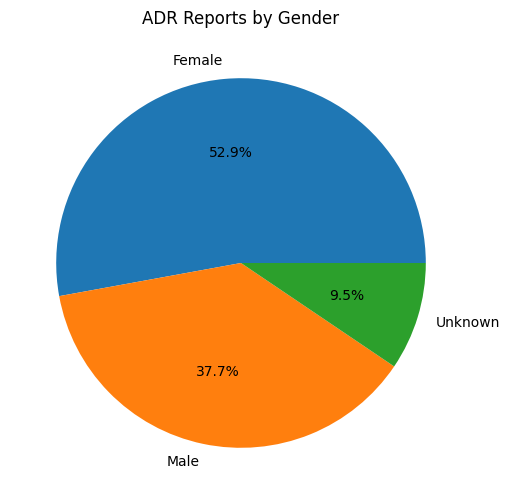

In [60]:
# ADR Reports by Gender

df['patient_sex'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6))

plt.title('ADR Reports by Gender')
plt.ylabel('')
plt.show()

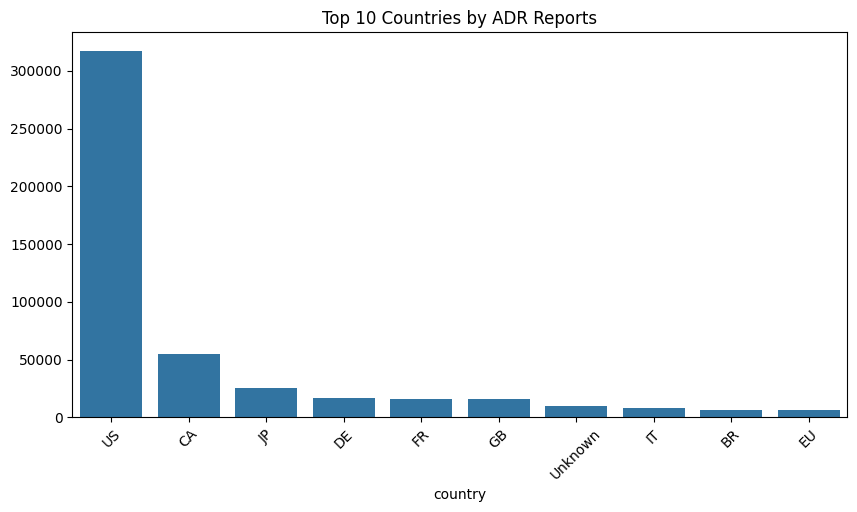

In [61]:
# Top Countries Reporting ADRs

top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.index,
            y=top_countries.values)

plt.title('Top 10 Countries by ADR Reports')
plt.xticks(rotation=45)
plt.show()

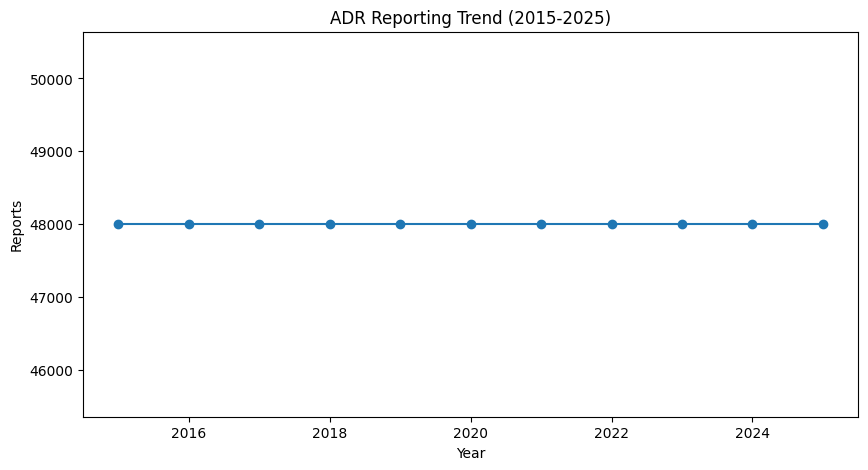

In [62]:
# ADR Trend by Year

yearly = df.groupby('year').size()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')

plt.title('ADR Reporting Trend (2015-2025)')
plt.xlabel('Year')
plt.ylabel('Reports')
plt.show()

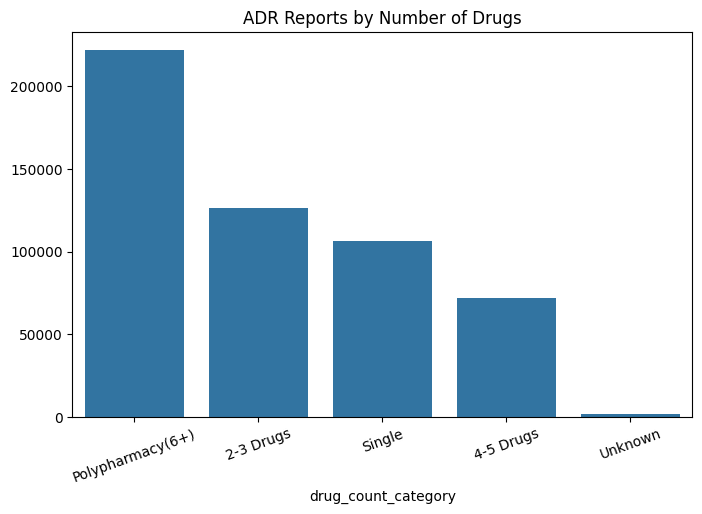

In [63]:
# ADR Reports by Drug Count Category

poly = df['drug_count_category'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=poly.index,
    y=poly.values)

plt.title('ADR Reports by Number of Drugs')
plt.xticks(rotation=20)
plt.show()

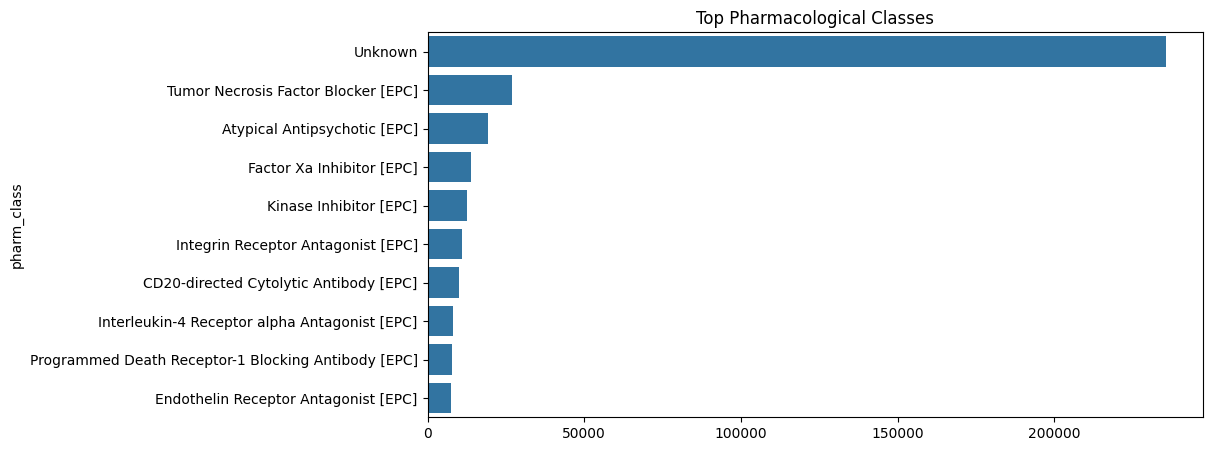

In [64]:
# Top Pharmacological Classes

top_class = df['pharm_class'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_class.values,
    y=top_class.index)

plt.title('Top Pharmacological Classes')
plt.show()

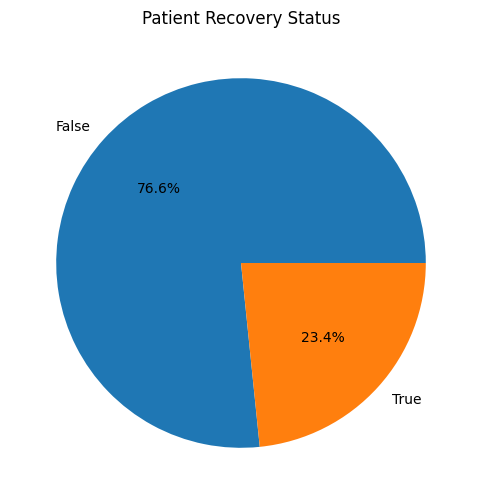

In [65]:
# Recovery Status

df['patient_recovered'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6))

plt.title('Patient Recovery Status')
plt.ylabel('')
plt.show()

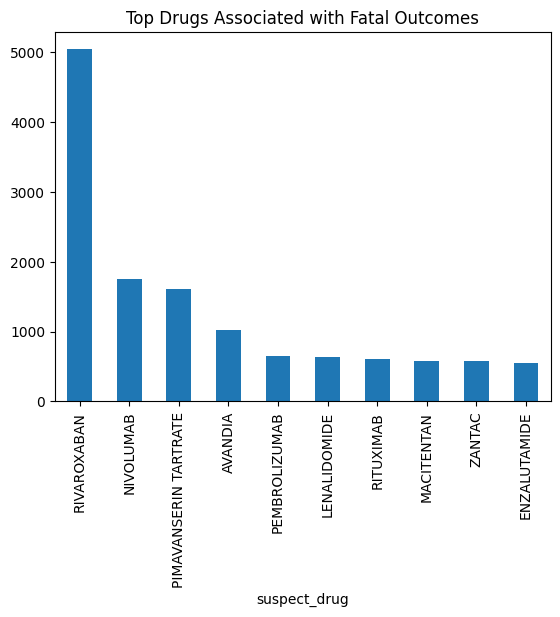

In [66]:
# Top 10 Fatality-Associated Drugs
fatal_drugs = df[df['is_fatal']==True]['suspect_drug']\
                .value_counts()\
                .head(10)

fatal_drugs.plot(kind='bar')
plt.title('Top Drugs Associated with Fatal Outcomes')
plt.show()

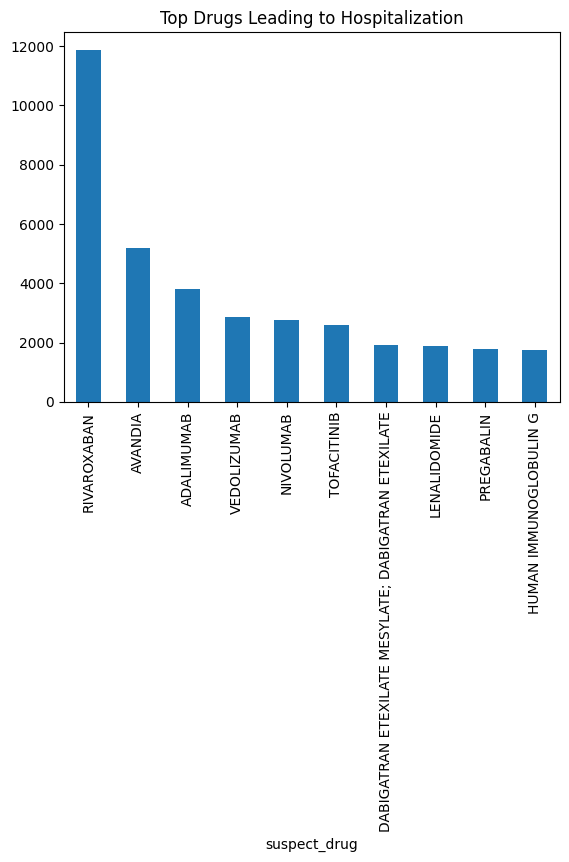

In [67]:
# Hospitalization Rate by Drug
hospitalized = df[df['is_hospitalized']==True]

hospitalized['suspect_drug']\
.value_counts()\
.head(10)\
.plot(kind='bar')

plt.title('Top Drugs Leading to Hospitalization')
plt.show()

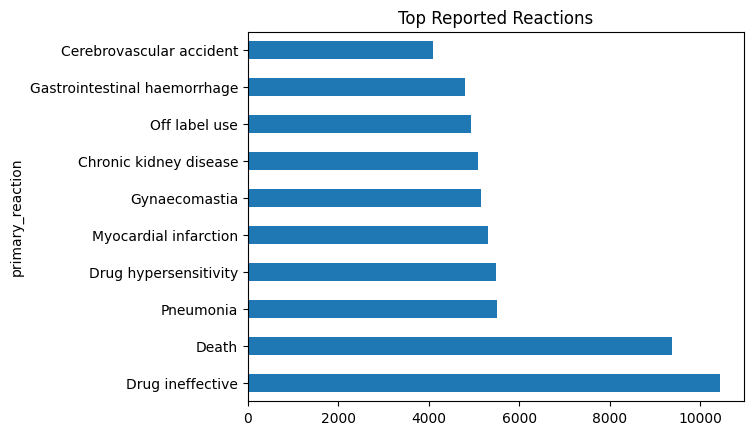

In [68]:
# Most Common Adverse Reactions
df['primary_reaction']\
.value_counts()\
.head(10)\
.plot(kind='barh')

plt.title('Top Reported Reactions')
plt.show()

In [69]:
df.to_csv("cleaned_drug_safety_data.csv", index=False)

In [70]:
!pip install sqlalchemy pymysql

In [71]:
import pymysql
from sqlalchemy import create_engine

# MySQL connection
# Replace placeholders with your actual details
username = "root"  
password = "admin123"  
host = "localhost" 
port = "3306" 
database = "drug_safety_analysis"  

# Create the connection engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}")

# Export your DataFrame to MySQL
table_name = "drug_safety_reports"         # Choose any table name
df.to_sql(table_name, engine, if_exists ="replace", index=False)


print("Data successfully loaded into MySQL!")

Data successfully loaded into MySQL!


In [72]:
# Read back sample
pd.read_sql(f"SELECT * FROM drug_safety_reports LIMIT 5;",engine)

,report_id,receive_date,year,month,quarter,serious,serious_flags,is_fatal,is_hospitalized,is_life_threat,...,manufacturer,pharm_class,num_drugs,drug_count_category,patient_age_years,age_group,patient_sex,patient_weight_kg,country,report_age_days
0,10004718,2015-02-11,2015,2,2015Q1,Yes,Hospitalization,0,1,0,...,Glaxosmithkline Llc,Unknown,7,Polypharmacy(6+),64.0,Middle-Aged(41-65),Female,Not Specified,US,4063
1,10004926,2015-02-13,2015,2,2015Q1,Yes,Hospitalization,0,1,0,...,Bayer Healthcare Pharmaceuticals Inc.,Progestin [EPC]; Progestin-containing Intraute...,1,Single,20.0,Adult(19-40),Female,54,US,4061
2,10005223,2015-02-19,2015,2,2015Q1,Yes,Hospitalization,0,1,0,...,Cordavis Limited; Abbvie Inc.,Unknown,14,Polypharmacy(6+),60.0,Middle-Aged(41-65),Female,Not Specified,US,4055
3,10005378,2015-02-17,2015,2,2015Q1,Yes,Hospitalization,0,1,0,...,Unknown,Unknown,34,Polypharmacy(6+),20.0,Adult(19-40),Female,Not Specified,BR,4057
4,10005980,2015-02-21,2015,2,2015Q1,Yes,Not Specified,0,0,0,...,Live Betr Llc; American Sales Company; Little ...,Unknown,7,Polypharmacy(6+),59.0,Unknown,Female,Not Specified,GB,4053
